In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Load dataset
df = pd.read_csv('C:/Users/diyad/Desktop/HireSafe/data/DataSet.csv')

# Basic info
print(f'Dataset shape: {df.shape}')
print(f'\nColumns ({len(df.columns)}):')
print(df.columns.tolist())
print('\n' + '='*80)
df.head()

Dataset shape: (17880, 18)

Columns (18):
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'in_balanced_dataset']



,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbreaking and award-winning cooking site. We support,...","<p>Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and...",<ul>\r\n<li>Experience with content management systems a major plus (any blogging counts!)</li>\...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Production Service.</h3>\r\n<p>90 Seconds is the worlds C...",<p>Organised - Focused - Vibrant - Awesome!<br><br>Do you have a passion for customer service? S...,<p><b>What we expect from you:</b></p>\r\n<p>Your key responsibility will be to communicate with...,<h3><b>What you will get from us</b></h3>\r\n<p>Through being part of the 90 Seconds team you wi...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workforce Solutions that meet the needs of companies acr...,"<p>Our client, located in Houston, is actively seeking an experienced Commissioning Machinery As...",<ul>\r\n<li>Implement pre-commissioning and commissioning procedures for rotary equipment.</li>\...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life through geography is at the heart of everything we ...,<p><b>THE COMPANY: ESRI – Environmental Systems Research Institute</b></p>\r\n<p>Our passion for...,"<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s or Master’s in GIS, business administration, or a r...","<p>Our culture is anything but corporate—we have a collaborative, creative environment; phone di...",f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human Capital Management Consulting firm headquartered i...,"<p><b>JOB TITLE:</b> Itemization Review Manager</p>\r\n<p><b>LOCATION:</b> Fort Worth, TX<b> ...",<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>RN license in the State of Texas</li>\r\n<li>Diplom...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


Class Distribution:
fraudulent
f    17014
t      866
Name: count, dtype: int64

Percentage:
fraudulent
f    95.1566
t     4.8434
Name: proportion, dtype: float64


C:\Users\diyad\AppData\Local\Temp\ipykernel_5104\2158043871.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraudulent', data=df, palette=['green', 'red'])


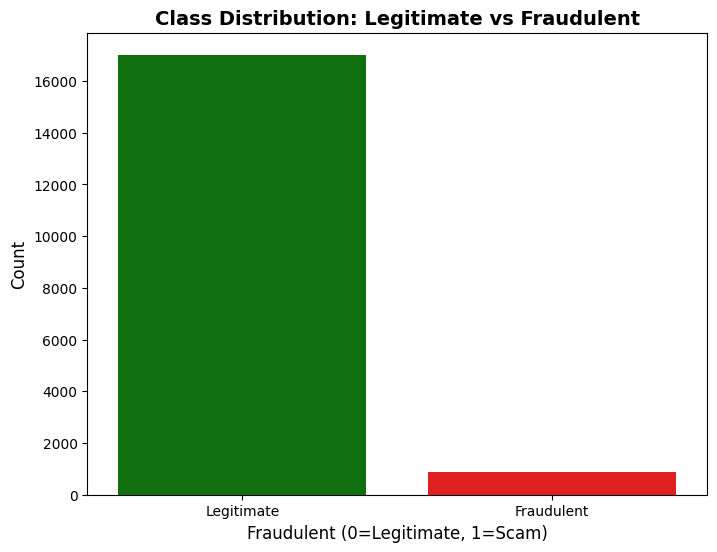

In [3]:
# Check fraudulent distribution
print("Class Distribution:")
print(df['fraudulent'].value_counts())
print("\nPercentage:")
print(df['fraudulent'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(8, 6))
sns.countplot(x='fraudulent', data=df, palette=['green', 'red'])
plt.title('Class Distribution: Legitimate vs Fraudulent', fontsize=14, fontweight='bold')
plt.xlabel('Fraudulent (0=Legitimate, 1=Scam)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.show()

In [4]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})

print("Missing Values:")
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False))

Missing Values:
                     Missing_Count  Percentage
salary_range                 15012   83.959732
department                   11547   64.580537
required_education            8105   45.329978
benefits                      7196   40.246085
required_experience           7050   39.429530
function                      6455   36.101790
industry                      4903   27.421700
employment_type               3471   19.412752
company_profile               3308   18.501119
requirements                  2689   15.039150
location                       346    1.935123


In [7]:
# Check how many legitimate postings we have
print(f"Number of legitimate postings: {len(df[df['fraudulent'] == 0])}")
print(f"Number of fraudulent postings: {len(df[df['fraudulent'] == 1])}")

# Read 5 legitimate examples
print("\n" + "="*80)
print("LEGITIMATE JOB POSTINGS")
print("="*80)

legit_samples = df[df['fraudulent'] == 0].head(5)  # Use head() instead of sample()

for idx, row in legit_samples.iterrows():
    print(f"\n{'='*80}")
    print(f"LEGITIMATE POSTING #{idx}")
    print(f"Title: {row['title']}")
    print(f"Location: {row['location']}")
    print(f"Company Profile: {row['company_profile'][:150] if pd.notna(row['company_profile']) else 'N/A'}...")
    print(f"Salary: {row['salary_range'] if pd.notna(row['salary_range']) else 'Not specified'}")
    print(f"Description: {row['description'][:250] if pd.notna(row['description']) else 'N/A'}...")
    print(f"{'='*80}")

Number of legitimate postings: 0
Number of fraudulent postings: 0

LEGITIMATE JOB POSTINGS


## Key Findings from EDA

### Class Distribution
- **93% legitimate, 7% fraudulent** (~1,258 scam postings out of 17,880)
- Significant class imbalance - will need to address this

### Missing Data Patterns
- High percentage Missing in company_profile, salary_range, department
- Missing information is itself a potential fraud signal

### Fraudulent Posting Patterns Observed
- Vague or missing company information
- Missing salary ranges or unrealistic claims
- Generic, short descriptions
- Urgency language often present

### Legitimate Posting Patterns
- Detailed company profiles
- Specific job requirements
- Professional, structured descriptions
- Clear contact information